In [31]:
import os
import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import scienceplots
plt.style.use(['science', 'no-latex'])

# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)


IMAGES_PATH = "/Users/klemenkubelj/Documents/school/graduate/masters/code/cvar-masters-thesis-2025/figures"

In [32]:
from utils.flood_request_utils import (
    get_damage_fraction,
    plot_damage_function_full_range,
    residential_damage_fractions,
    commercial_damage_function,
    industrial_damage_function,
    agriculture_damage_function,

    get_wri_and_si_hazard_data,
    plot_wri_and_si_hazard_data,
    get_damage_fraction,
)

In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Depth-Damage Function

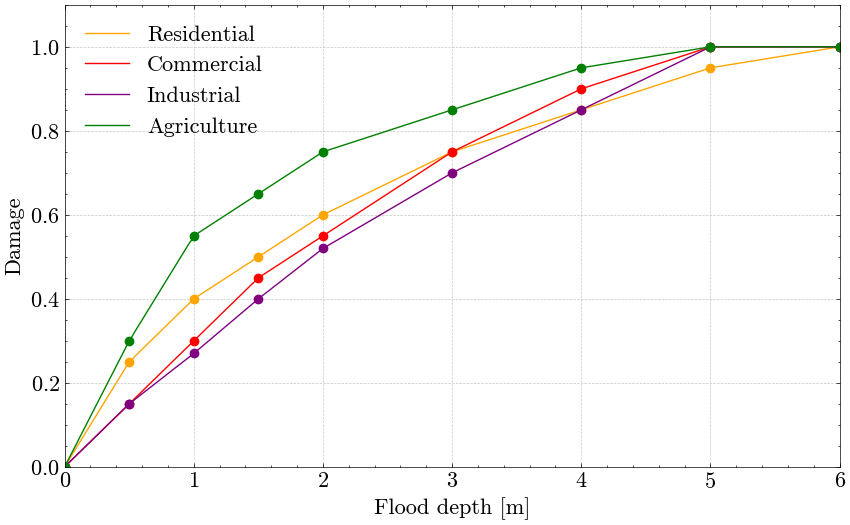

In [ ]:
plot_damage_function_full_range("residential", color="orange", label="Residential")
plot_damage_function_full_range("commercial", color="red", label="Commercial")
plot_damage_function_full_range("industrial", color="purple", label="Industrial")
fig, ax = plot_damage_function_full_range("agriculture", color="green", label="Agriculture")
# plt.grid()
# plt.title("Flood Depth-Damage Function (Europe)")

# Set fontsize of legent to 20
plt.rcParams.update({'font.size': 16})

plt.xlim(0, 6)
plt.ylim(0, 1.1)
plt.legend()

plt.gcf().set_size_inches(10, 6)
plt.savefig(IMAGES_PATH + "/03/vulnerability_curve_europe.pdf", dpi=300, bbox_inches="tight")
# Make wider


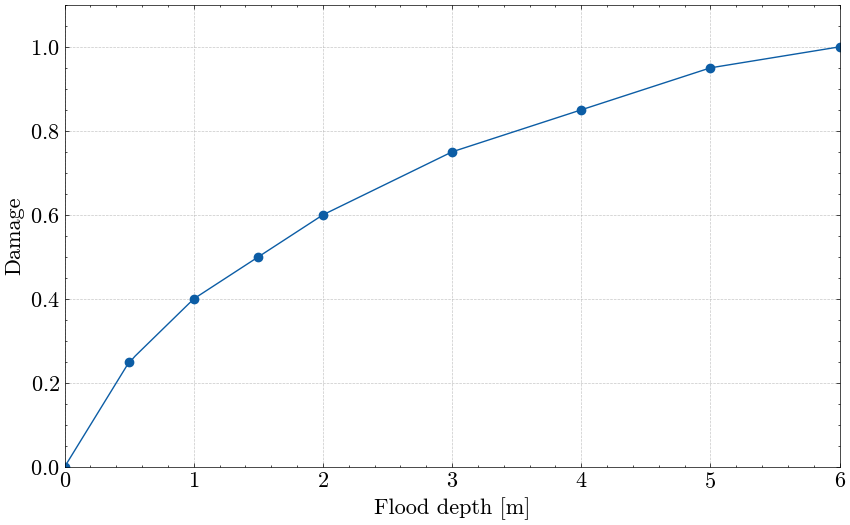

In [65]:
fig, ax = plot_damage_function_full_range("residential", color="C0", label="Residential")
# plt.grid()
# plt.title("Flood Depth-Damage Function (Europe)")

# Set fontsize of legent to 20
plt.rcParams.update({'font.size': 16})

plt.xlim(0, 6)
plt.ylim(0, 1.1)
# plt.legend()

plt.gcf().set_size_inches(10, 6)
plt.savefig(IMAGES_PATH + "/03/vulnerability_curve_europe_residential.pdf", dpi=300, bbox_inches="tight")


# EAD

In [35]:
litija_1 = {
    "lng": 14.836790,
    "lat": 46.060307
}
litija_2 = {
    "lng": 14.821837,
    "lat": 46.056977
}

Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!


/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_34841/2870438781.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


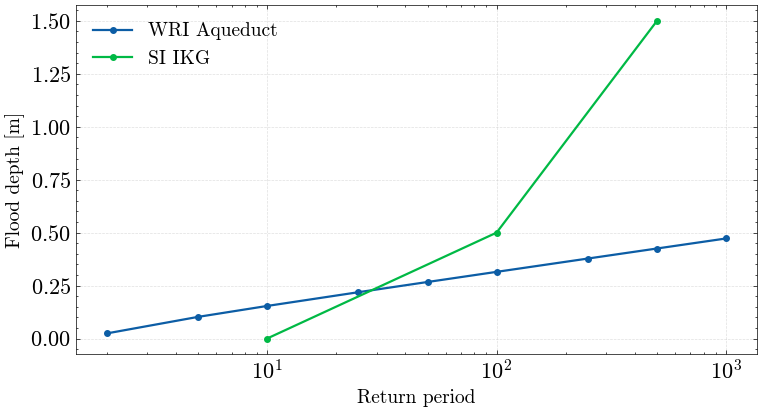

In [67]:
data, request = get_wri_and_si_hazard_data(litija_1)
fig = plot_wri_and_si_hazard_data(data, request)#, x_axis="AEP")
fig.savefig(IMAGES_PATH + "/03/ikg_and_wri_for_one_point_example.pdf", dpi=300, bbox_inches="tight")
fig.show()

Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!


/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_34841/864257472.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


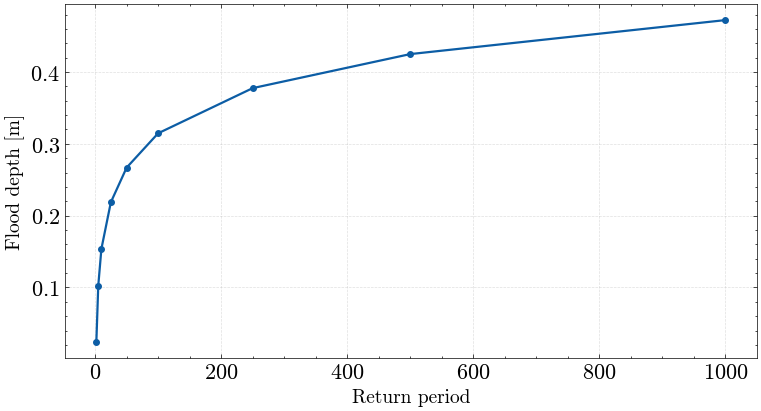

In [68]:
data, request = get_wri_and_si_hazard_data(litija_1)
fig = plot_wri_and_si_hazard_data(data, request, plot_from=["wri"], logscale=False, show_legend=False)
fig.savefig(IMAGES_PATH + "/03/flood_depth_example_litija_curve.pdf", dpi=300, bbox_inches="tight")
fig.show()

/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_34841/952465868.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


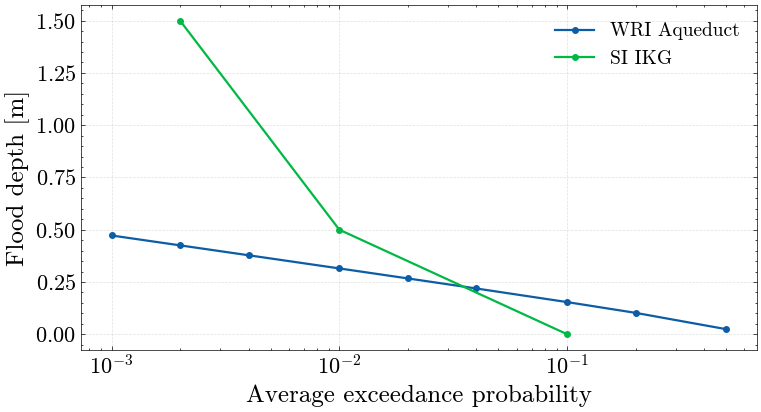

In [38]:
fig = plot_wri_and_si_hazard_data(data, request, x_axis="AEP", legend_loc="upper right")
fig.show()

In [43]:
return_periods = data["items"][0]["intensity_curve_set"][0]["index_values"]
exceeded_probabilities = [1 / rp for rp in return_periods]
depths = data["items"][0]["intensity_curve_set"][0]["intensities"]
damage_fractions = [get_damage_fraction(depth) for depth in depths]

value = 100000 # 100k EUR
damage_total = [value * df for df in damage_fractions]


print("return_periods: ", return_periods)
print("exceeded_probabilities: ", exceeded_probabilities)

print("depths: ", depths)
print("damage_fractions: ", damage_fractions)
print("damage_total: ", damage_total)

Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
return_periods:  [2.0, 5.0, 10.0, 25.0, 50.0, 100.0, 250.0, 500.0, 1000.0]
exceeded_probabilities:  [0.5, 0.2, 0.1, 0.04, 0.02, 0.01, 0.004, 0.002, 0.001]
depths:  [0.02401801198720932, 0.10212962329387665, 0.1537131667137146, 0.21867892146110535, 0.2668743133544922, 0.3147137761116028, 0.37761956453323364, 0.4250403046607971, 0.4723888039588928]
damage_fractions:  [0.01200900599360466, 0.051064811646938324, 0.0768565833568573, 0

In [46]:
def bplot(x, y, xlabel, ylabel, logx: bool = False, color="C0"):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(x, y, "o", color=color)
    ax.plot(x, y, color=color)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if logx:
        plt.xscale("log")

    # Add grid lines for both x and y axes
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.grid(True, axis="x", which="both",  linestyle="--", alpha=0.5)
    fig.tight_layout()

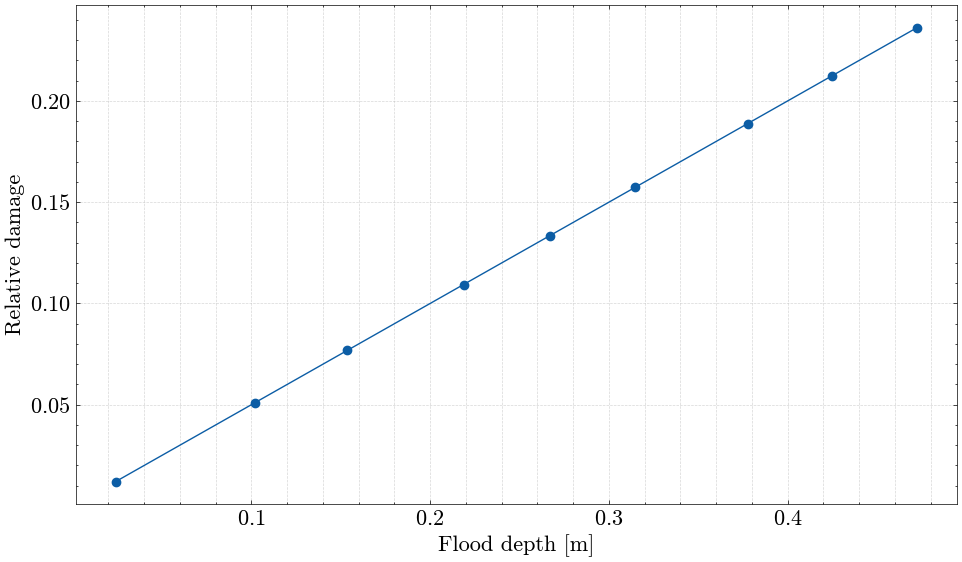

In [47]:
bplot(depths, damage_fractions, "Flood depth [m]", "Relative damage")

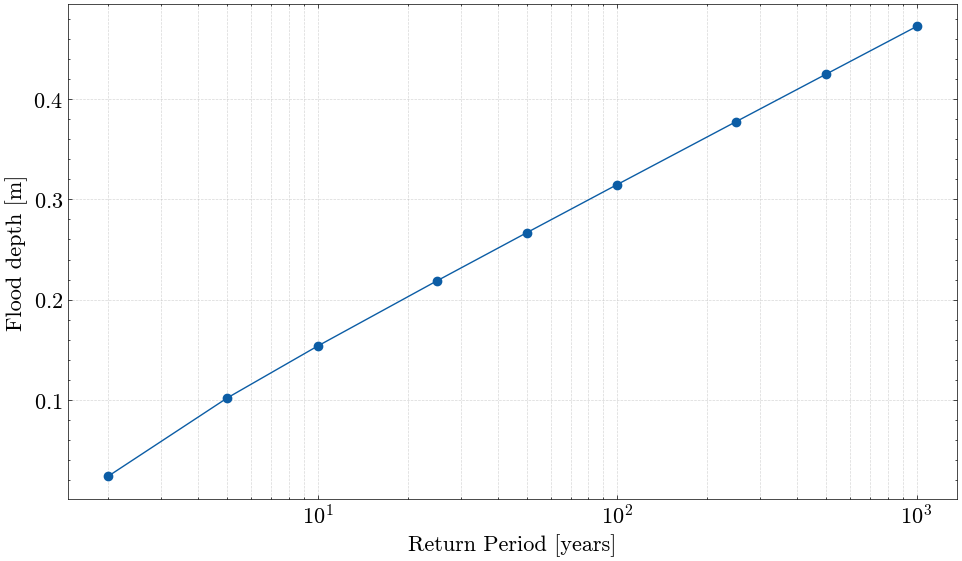

In [48]:
bplot(return_periods, depths, "Return Period [years]", "Flood depth [m]", logx=True)

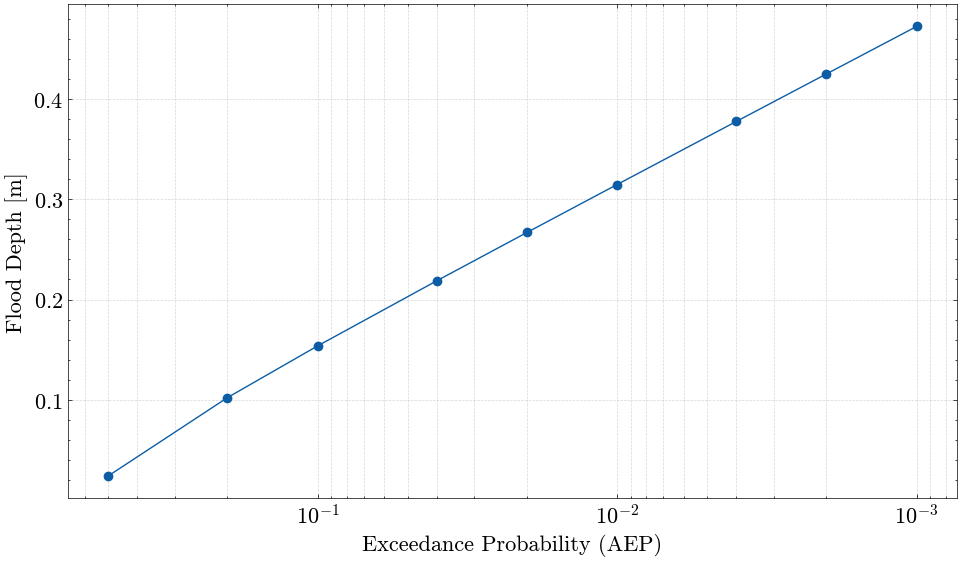

In [49]:
bplot(exceeded_probabilities, depths, "Exceedance Probability (AEP)", "Flood Depth [m]", logx=True)
plt.gca().invert_xaxis()

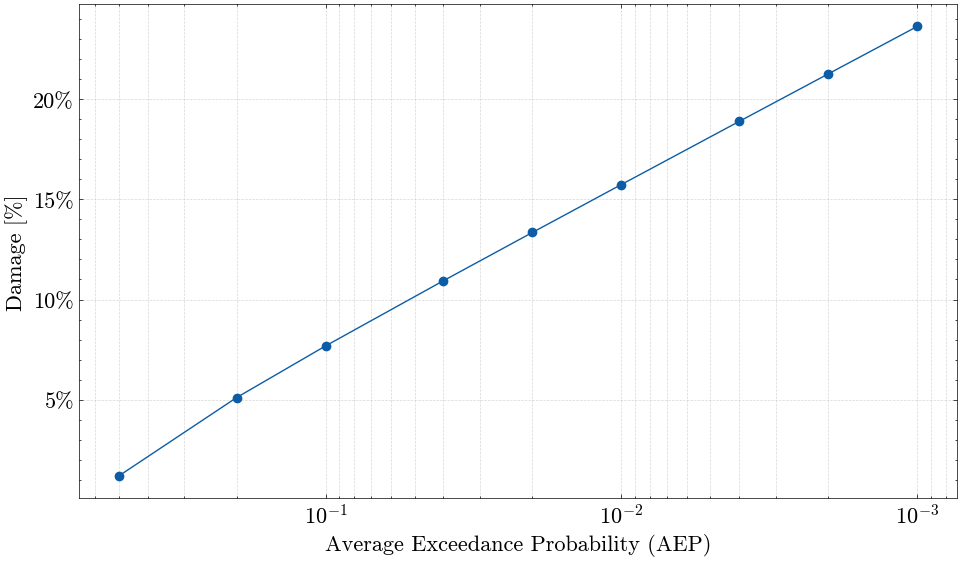

In [50]:
bplot(exceeded_probabilities, damage_fractions, "Average Exceedance Probability (AEP)", "Damage [%]", logx=True)
# Set y to % (whole number) instead of decimal
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.gca().invert_xaxis()

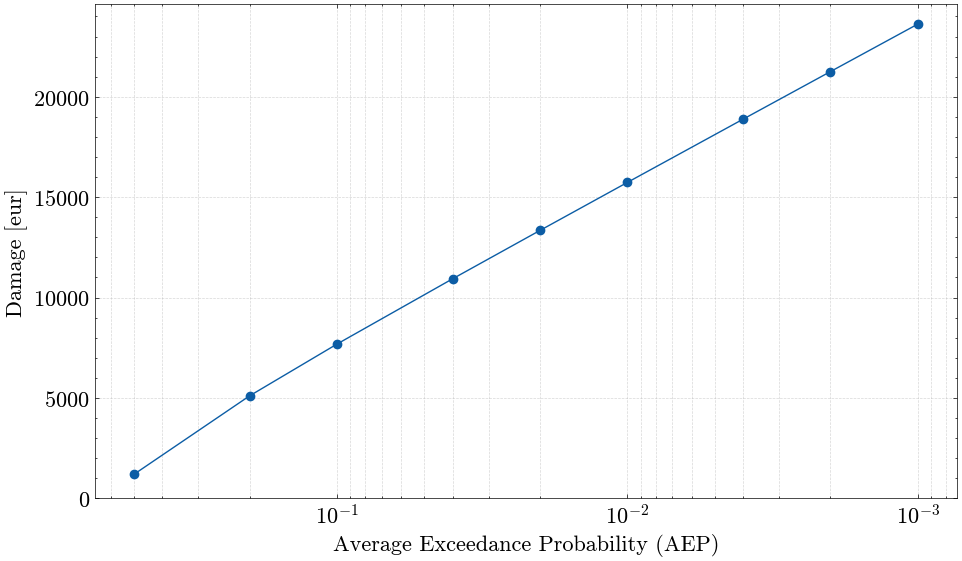

In [51]:
bplot(exceeded_probabilities, damage_total, "Average Exceedance Probability (AEP)", "Damage [eur]", logx=True)
plt.ylim(0, max(damage_total)+1000)
plt.gca().invert_xaxis()

In [52]:
# import matplotlib as mpl
# mpl.rcParams.update({
#     "text.usetex": False,
#     "mathtext.fontset": "dejavusans",
#     "font.family": "DejaVu Sans",
# })

Text(0.7, 0.1, 'EAD: 2699$€$')

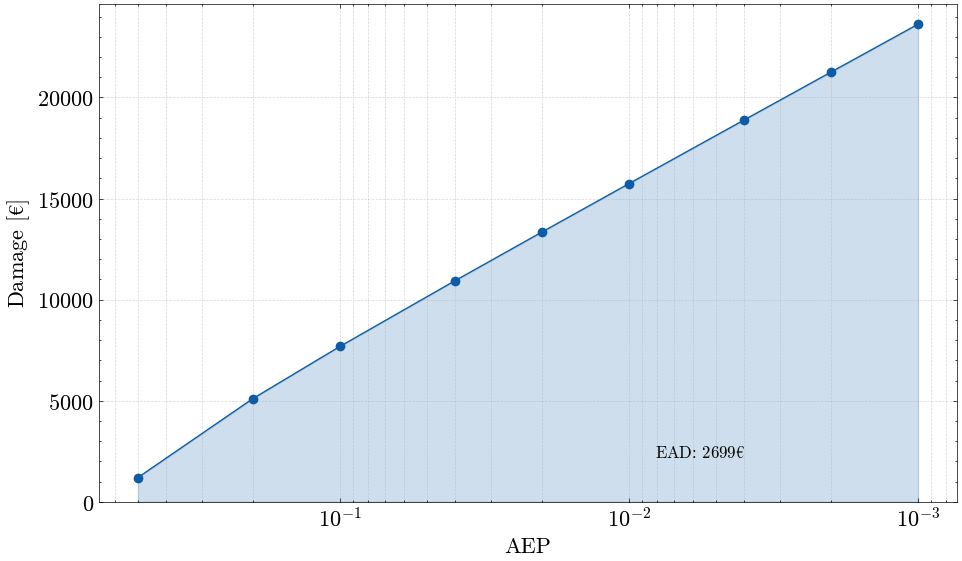

In [58]:
bplot(exceeded_probabilities, damage_total, "AEP", "Damage [$€$]", logx=True)
plt.ylim(0, max(damage_total)+1000)
plt.gca().invert_xaxis()

# Calculate and display the area under the curve
area_under_curve = abs(np.trapz(damage_total, x=exceeded_probabilities))
plt.fill_between(exceeded_probabilities, damage_total, alpha=0.2, color="C0")
plt.text(0.7, 0.1, f"EAD: {area_under_curve:.0f}$€$", transform=plt.gca().transAxes, fontsize=12, verticalalignment='center', horizontalalignment='center')

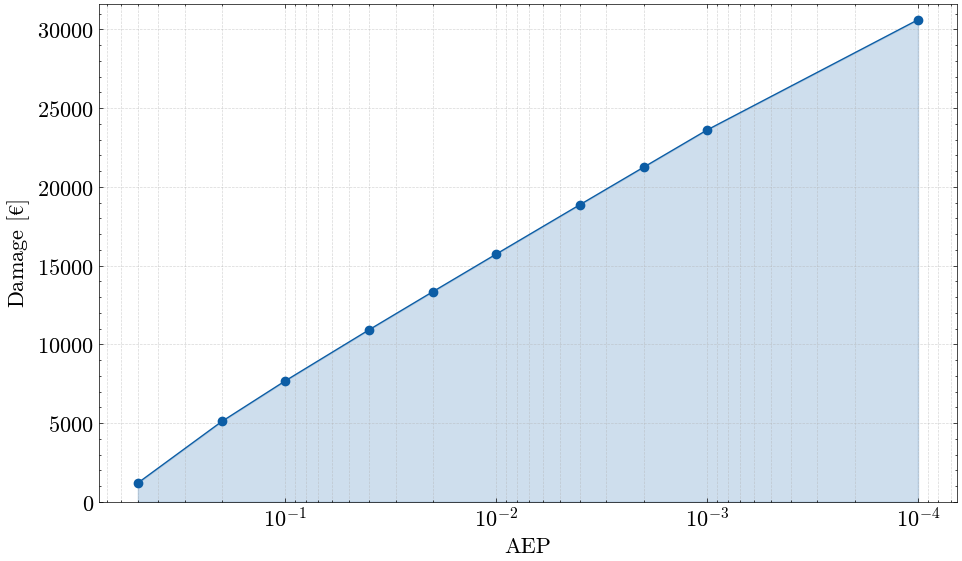

In [60]:
x = exceeded_probabilities + [10**-4,]
y = damage_total + [30619]
bplot(x, y, "AEP", "Damage [$€$]", logx=True)
plt.ylim(0, max(y)+1000)
plt.gca().invert_xaxis()

# Calculate and display the area under the curve
area_under_curve = abs(np.trapz(y, x=x))
plt.fill_between(x, y, alpha=0.2, color="C0")

plt.savefig(IMAGES_PATH + "/03/ead_plot_example.pdf", dpi=300, bbox_inches="tight")
# plt.text(0.7, 0.1, f"EAD", transform=plt.gca().transAxes, fontsize=12, verticalalignment='center', horizontalalignment='center')
# plt.text(0.7, 0.1, f"EAD: {area_under_curve:.2f} €", transform=plt.gca().transAxes, fontsize=12, verticalalignment='center', horizontalalignment='center')